In [4]:
import numpy as np
import pandas as pd
import sklearn
import scipy
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, accuracy_score
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.svm import OneClassSVM
from pylab import rcParams
rcParams['figure.figsize'] = 14, 8
RANDOM_SEED = 42
LABELS = ["Normal", "Fraud"]

In [5]:
from google.colab import files
upload = files.upload()

Saving creditcard.csv to creditcard.csv


In [6]:
data = pd.read_csv('creditcard.csv',sep=',')
data.head()

,CustomerID,A1,A2,A3,A4,A5,A6,A7,A8,A9,A10,A11,A12,A13,A14,Class
0,15776156,1,22.08,11.46,2,4,4,1.585,0,0,0,1,2,100,1213,0
1,15739548,0,22.67,7.00,2,8,4,0.165,0,0,0,0,2,160,1,0
2,15662854,0,29.58,1.75,1,4,4,1.250,0,0,0,1,2,280,1,0
3,15687688,0,21.67,11.50,1,5,3,0.000,1,1,11,1,2,0,1,1
4,15715750,1,20.17,8.17,2,6,4,1.960,1,1,14,0,2,60,159,1


In [7]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 690 entries, 0 to 689
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   CustomerID  690 non-null    int64  
 1   A1          690 non-null    int64  
 2   A2          690 non-null    float64
 3   A3          690 non-null    float64
 4   A4          690 non-null    int64  
 5   A5          690 non-null    int64  
 6   A6          690 non-null    int64  
 7   A7          690 non-null    float64
 8   A8          690 non-null    int64  
 9   A9          690 non-null    int64  
 10  A10         690 non-null    int64  
 11  A11         690 non-null    int64  
 12  A12         690 non-null    int64  
 13  A13         690 non-null    int64  
 14  A14         690 non-null    int64  
 15  Class       690 non-null    int64  
dtypes: float64(3), int64(13)
memory usage: 86.4 KB


In [8]:
data.isnull().values.any()

np.False_

/tmp/ipykernel_1032/1143868770.py:1: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  count_classes = pd.value_counts(data['Class'], sort = True)


Text(0, 0.5, 'Frequency')

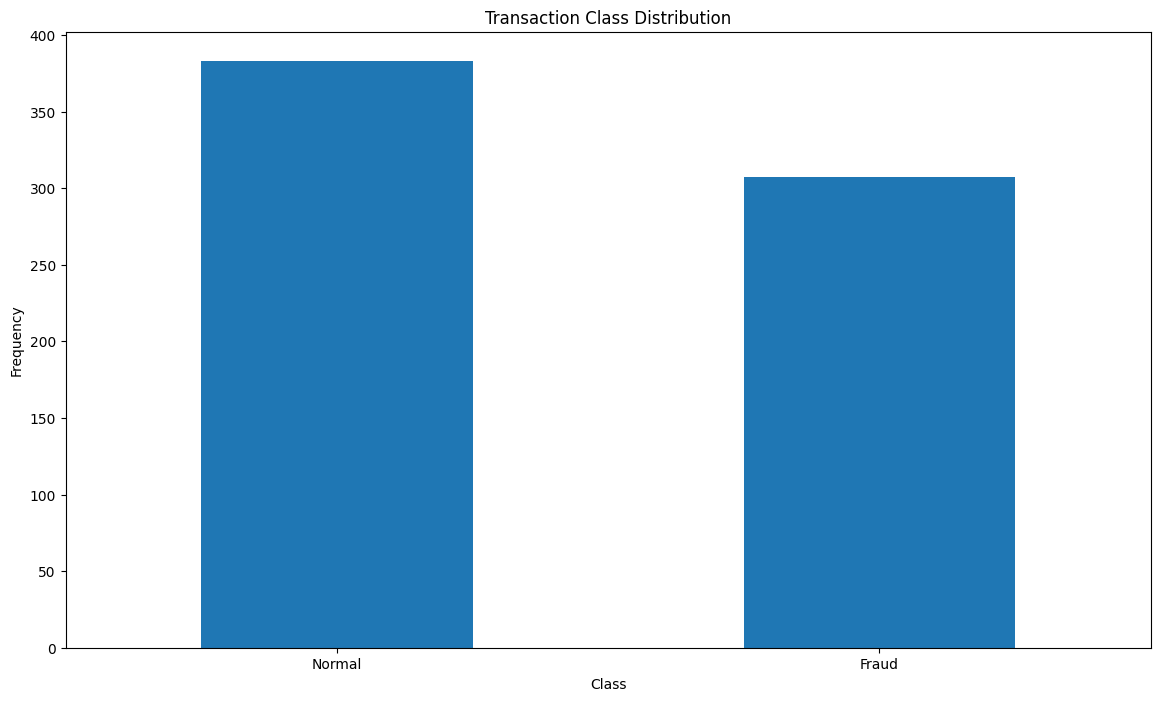

In [9]:
count_classes = pd.value_counts(data['Class'], sort = True)
count_classes.plot(kind = 'bar', rot=0)
plt.title("Transaction Class Distribution")
plt.xticks(range(2), LABELS)
plt.xlabel("Class")
plt.ylabel("Frequency")

In [10]:
fraud = data[data['Class']==1]
normal = data[data['Class']==0]
print(fraud.shape,normal.shape)

(307, 16) (383, 16)


In [12]:
fraud.A14.describe()

,A14
count,307.000000
mean,2039.859935
std,7659.763941
min,1.000000
25%,1.000000
50%,222.000000
75%,1210.000000
max,100001.000000


In [17]:
normal.A14.describe()

,A14
count,383.000000
mean,199.605744
std,671.608839
min,1.000000
25%,1.000000
50%,2.000000
75%,68.000000
max,5553.000000


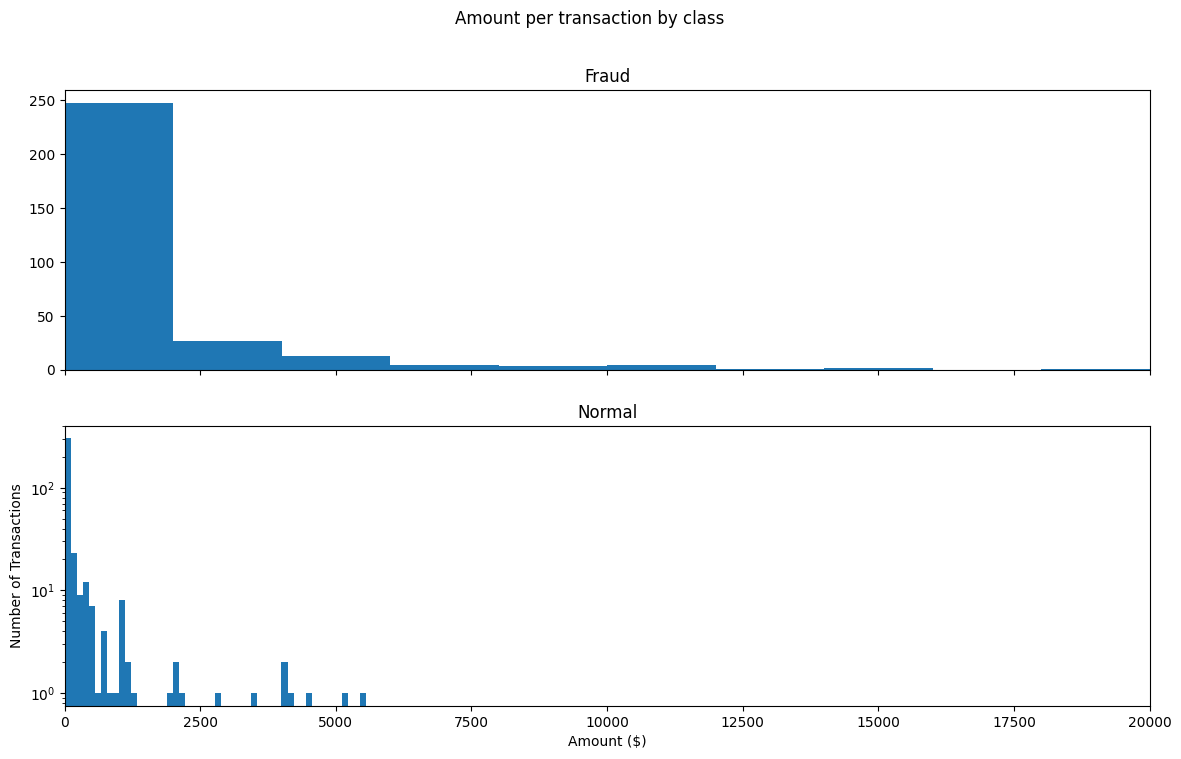

In [19]:
f, (ax1, ax2) = plt.subplots(2, 1, sharex=True)
f.suptitle('Amount per transaction by class')
bins = 50
ax1.hist(fraud.A14,bins = bins)
ax1.set_title('Fraud')
ax2.hist(normal.A14,bins = bins)
ax2.set_title('Normal')
plt.xlabel('Amount ($)')
plt.ylabel('Number of Transactions')
plt.xlim((0,20000))
plt.yscale('log')
plt.show();

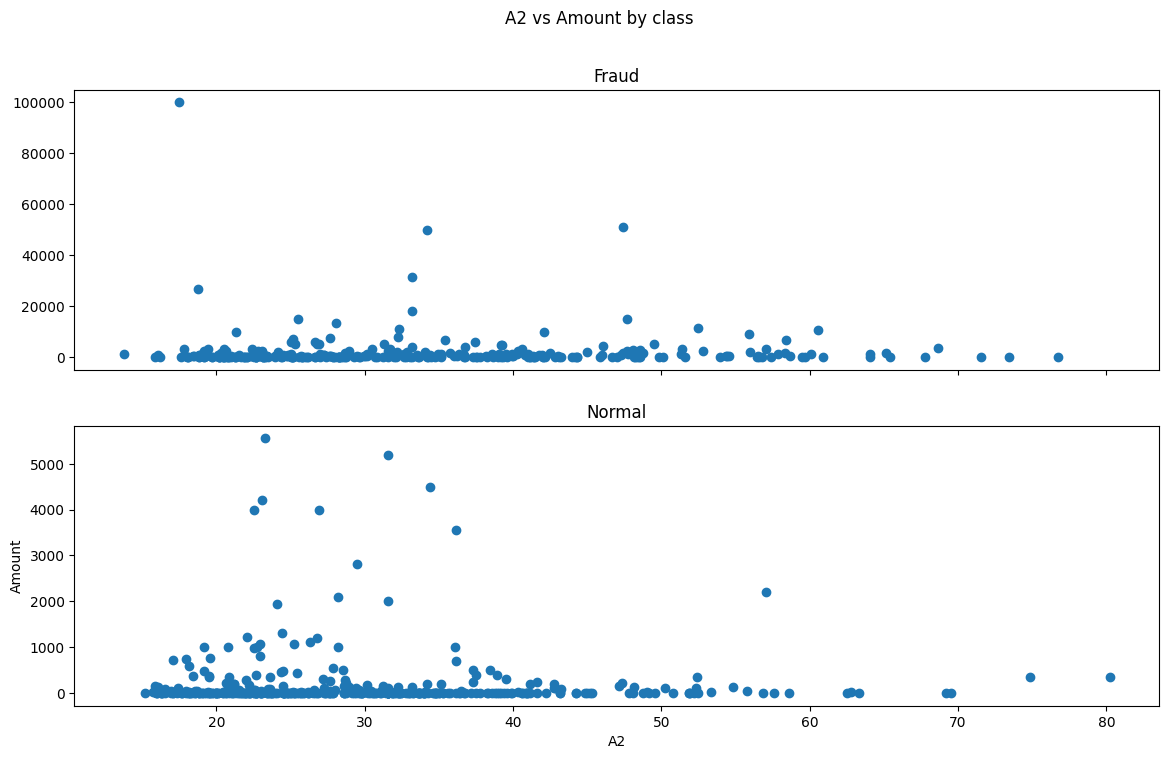

In [26]:
f, (ax1, ax2) = plt.subplots(2, 1, sharex=True)
f.suptitle('A2 vs Amount by class')
ax1.scatter(fraud.A2,fraud.A14)
ax1.set_title('Fraud')
ax2.scatter(normal.A2, normal.A14)
ax2.set_title('Normal')
plt.xlabel('A2')
plt.ylabel('Amount')
plt.show()

In [27]:
data= data.sample(frac = 0.1,random_state=1)
data.shape

(69, 16)

In [35]:
Fraud = data[data['Class']==1]
Valid = data[data['Class']==0]
# outlier_fraction is now calculated in the next cell (Lvimu2Wolrgq)

# Print the results, assuming outlier_fraction is set correctly in the next cell
# For display purposes, we can print the proportion based on the current data state
outlier_fraction_display = len(Fraud) / float(len(data))
outlier_fraction_display = min(outlier_fraction_display, 0.5)

print(outlier_fraction_display)
print("Fraud Cases : {}".format(len(Fraud)))
print("Valid Cases : {}".format(len(Valid)))

0.5
Fraud Cases : 38
Valid Cases : 31


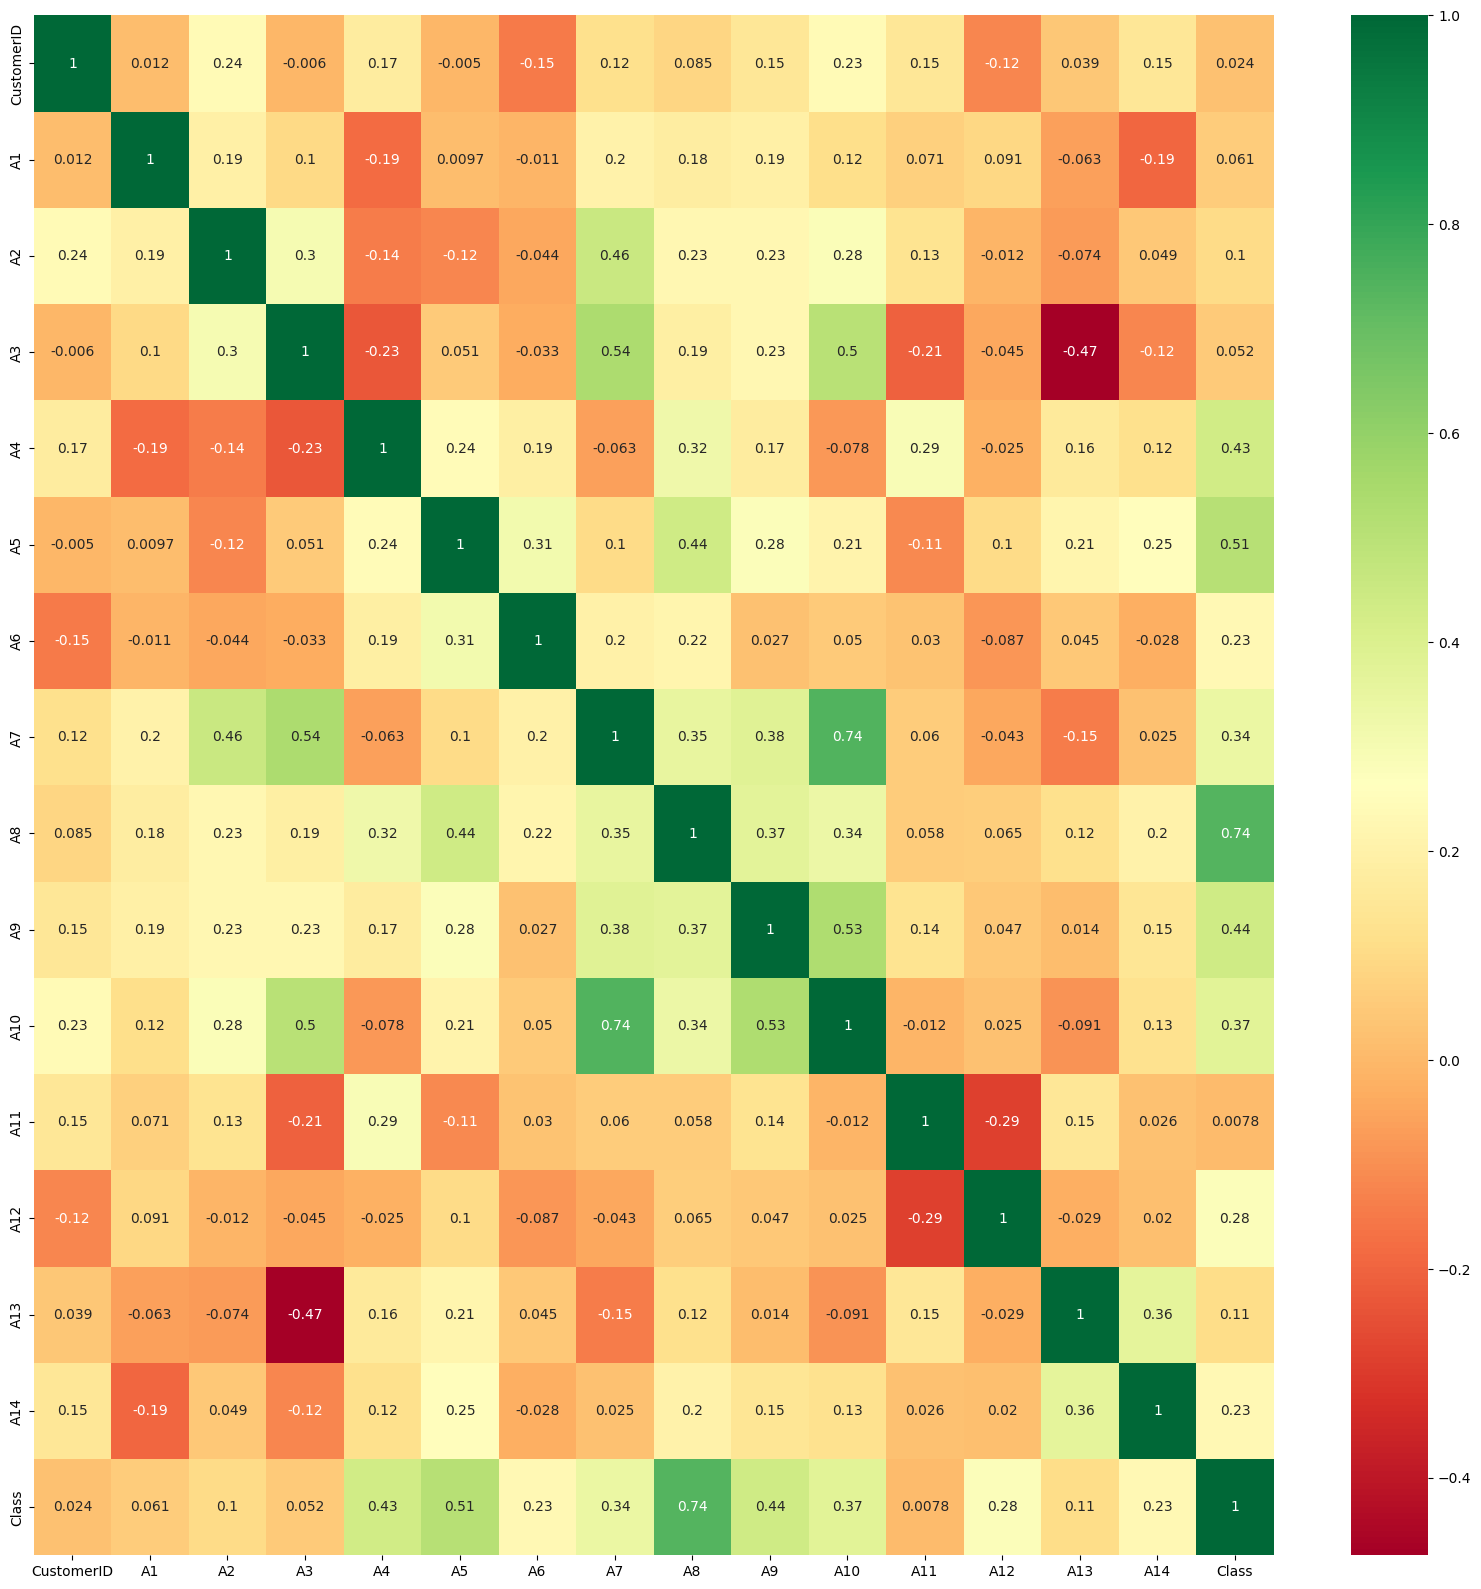

In [31]:
import seaborn as sns
corrmat = data.corr()
top_corr_features = corrmat.index
plt.figure(figsize=(20,20))
g=sns.heatmap(data[top_corr_features].corr(),annot=True,cmap="RdYlGn")

In [32]:
columns = data.columns.tolist() # Filter the columns to remove data we do not want
columns = [c for c in columns if c not in ["Class"]]
# Store the variable we are predicting
target = "Class"
# Define a random state
state = np.random.RandomState(42)
X = data[columns]
Y = data[target]
X_outliers = state.uniform(low=0, high=1, size=(X.shape[0],X.shape[1]))
# Print the shapes of X & Y
print(X.shape)
print(Y.shape)

(69, 15)
(69,)


In [36]:
Fraud = data[data['Class']==1]
Valid = data[data['Class']==0]
outlier_fraction = len(Fraud)/float(len(data))
outlier_fraction = min(outlier_fraction, 0.5) # Cap at 0.5 as required by IsolationForest

classifiers = {
    "Isolation Forest": IsolationForest(
        n_estimators=100,
        max_samples=len(X),
        contamination=outlier_fraction,
        random_state=state,
        verbose=0
    ),
    "Local Outlier Factor": LocalOutlierFactor(
        n_neighbors=20,
        algorithm='auto',
        leaf_size=30,
        metric='minkowski',
        p=2,
        metric_params=None,
        contamination=outlier_fraction
    )
}
n_outliers = len(Fraud)

for i, (clf_name, clf) in enumerate(classifiers.items()):
    # Fit the data and tag outliers
    if clf_name == "Local Outlier Factor":
        y_pred = clf.fit_predict(X)
        scores_prediction = clf.negative_outlier_factor_
    else:
        clf.fit(X)
        scores_prediction = clf.decision_function(X)
        y_pred = clf.predict(X)

    # Reshape the prediction values to 0 for Valid transactions, 1 for Fraud transactions
    y_pred[y_pred == 1] = 0
    y_pred[y_pred == -1] = 1

    n_errors = (y_pred != Y).sum()

    # Run Classification Metrics
    print("{}: {}".format(clf_name, n_errors))
    print("Accuracy Score :")
    print(accuracy_score(Y, y_pred))
    print("Classification Report :")
    print(classification_report(Y, y_pred))

Isolation Forest: 34
Accuracy Score :
0.5072463768115942
Classification Report :
              precision    recall  f1-score   support

           0       0.46      0.52      0.48        31
           1       0.56      0.50      0.53        38

    accuracy                           0.51        69
   macro avg       0.51      0.51      0.51        69
weighted avg       0.51      0.51      0.51        69

Local Outlier Factor: 36
Accuracy Score :
0.4782608695652174
Classification Report :
              precision    recall  f1-score   support

           0       0.43      0.48      0.45        31
           1       0.53      0.47      0.50        38

    accuracy                           0.48        69
   macro avg       0.48      0.48      0.48        69
weighted avg       0.48      0.48      0.48        69

